# Análisis de tecnologías de la información: Nubes (Cloud)

## Cargando librerías y los conjuntos de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import utils as u

In [2]:
df_platforms = pd.read_parquet('datos/platforms.parquet')
df_respondents = pd.read_parquet('datos/respondents.parquet')
df_platforms_metrics = pd.read_parquet('datos/platforms_metrics.parquet')

## Plataformas principales

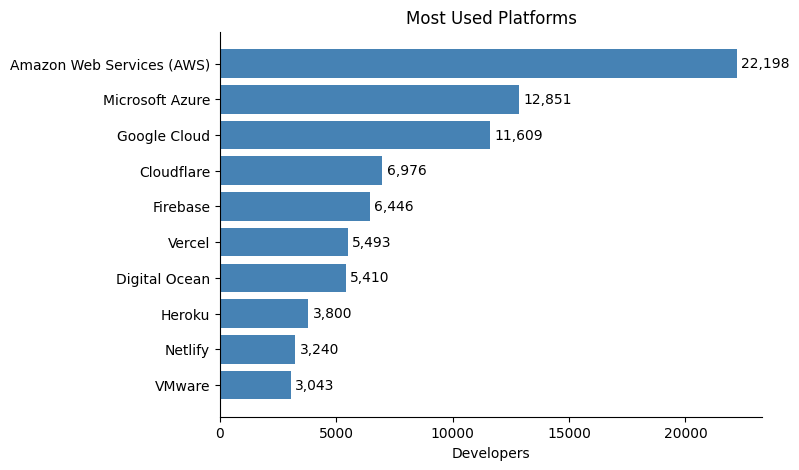

In [3]:
ax_pf_have = u.bars_plot(df_platforms_metrics, 'HaveWorkedWith', 'Platform', 'Most Used Platforms')
plt.show()

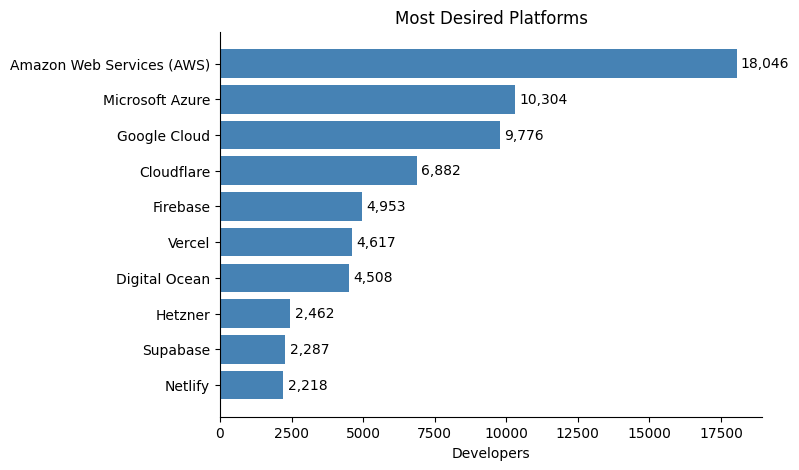

In [4]:
ax_pf_want = u.bars_plot(df_platforms_metrics, 'WantToWorkWith', 'Platform', 'Most Desired Platforms')
plt.show()

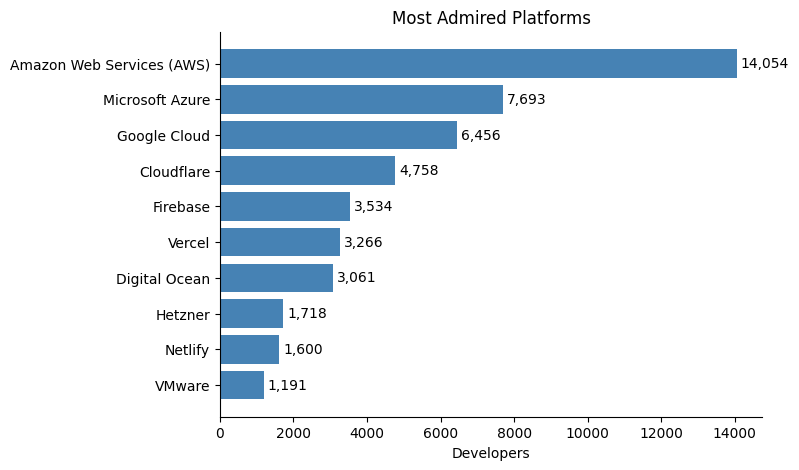

In [5]:
ax_pf_adm = u.bars_plot(df_platforms_metrics, 'Admired', 'Platform', 'Most Admired Platforms')
plt.show()

- Las plataformas cloud muestran una alta consistencia entre uso actual, interés futuro y admiración. Siete plataformas —AWS, Azure, Google Cloud, Cloudflare, Firebase, Vercel y DigitalOcean— aparecen simultáneamente en el Top 8 de uso, deseo y admiración, lo que sugiere una fuerte alineación entre adopción del mercado y preferencia de los desarrolladores.
- La principal diferencia se observa en la octava posición: Heroku aparece en el Top 8 de uso actual, mientras que Hetzner destaca en las métricas de interés y admiración, lo que podría indicar un cambio gradual en las preferencias hacia proveedores de infraestructura más económicos o especializados.

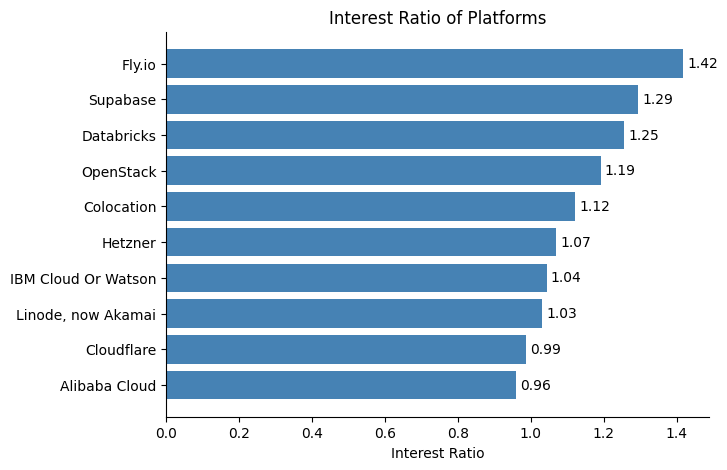

In [6]:
ax_int_ratio = u.bars_plot(df_platforms_metrics, 'InterestRatio', 'Platform', 'Interest Ratio of Platforms', fmt = '{:.2f}', xlabel='Interest Ratio')
plt.show()

Fly.io, Supabase y Databricks tienen un alto indice de preferencia, indicando un fuerte interes por parte de los profesionales de TI, pese a ser plataformas de baja adopcion en este último año.

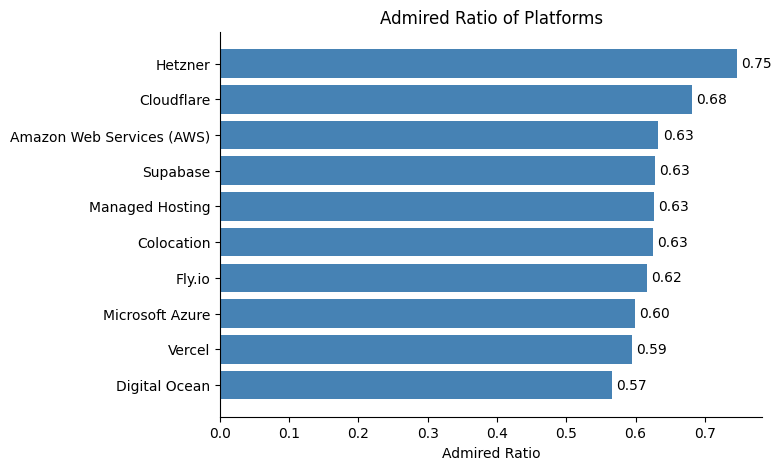

In [7]:
ax_adm_ratio = u.bars_plot(df_platforms_metrics, 'AdmiredRatio', 'Platform', 'Admired Ratio of Platforms', fmt = '{:.2f}', xlabel='Admired Ratio')
plt.show()

**Nota**
- La métrica AdmiredRate representa la proporción de desarrolladores que desean seguir utilizando una plataforma entre quienes ya la han usado.
- Es importante considerar que plataformas con una base de usuarios pequeña pueden mostrar tasas de admiración más altas con mayor facilidad, por lo que los resultados deben interpretarse junto con el tamaño de adopción de cada plataforma.

- Hetzner presenta la mayor tasa de admiración (0.75), seguida por Cloudflare (0.68) y Amazon Web Services (0.63), lo que indica que una alta proporción de quienes utilizan estas plataformas desean continuar trabajando con ellas.
- Las plataformas con mayor tasa de admiración no necesariamente coinciden con aquellas con mayor base de usuarios. Algunas plataformas con menor adopción muestran tasas de admiración elevadas, lo que sugiere una alta fidelidad entre sus usuarios actuales.

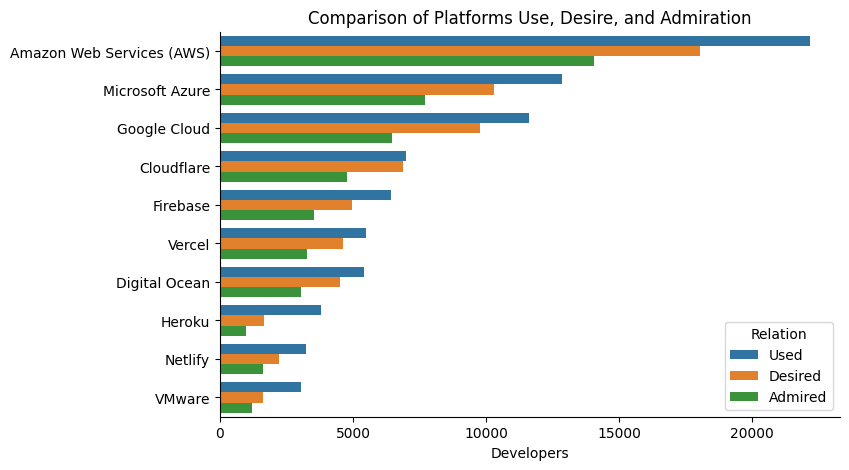

In [8]:
ax_comp = u.bar_comparative_plot(df_platforms_metrics, 'Platform', 'Comparison of Platforms Use, Desire, and Admiration')
plt.show()

- AWS, Azure y Google Cloud muestran la mayor adopción, lo que confirma su posición dominante en el ecosistema cloud.
- AWS sigue siendo la plataforma más deseada, lo que indica que su liderazgo probablemente continuará.
- Cloudflare y Firebase muestran una relación relativamente equilibrada entre uso, deseo y admiración, sugiriendo buena percepción entre los desarrolladores.
- Vercel, DigitalOcean, Netlify y Heroku tienen menor adopción, pero mantienen niveles relevantes de interés, lo que sugiere uso en nichos específicos.

Debido a que el número total de respuestas para HaveWorkedWith, WantToWorkWith y Admired no es el mismo, las barras no representan proporciones comparables entre categorías. Por lo tanto, este gráfico se utiliza principalmente para observar tendencias relativas dentro de cada métrica, mientras que los análisis comparativos entre plataformas se realizan mediante tasas normalizadas como Preference Rate o Admiration Rate.

In [9]:
x_median = df_platforms_metrics['HaveWorkedWith'].median()
df_plot = u.assign_quadrant(
    df_platforms_metrics, 
    'HaveWorkedWith', 
    'InterestRatio', 
    x_median, 
    1, 
    'MarketQuadrant',
    'Growth',
    'Emerging',
    'Declining',
    'Mature'
)

growth   = df_plot[df_plot['MarketQuadrant'] == 'Growth'].nlargest(4, 'HaveWorkedWith')
emerging  = df_plot[df_plot['MarketQuadrant'] == 'Emerging'].nlargest(4, 'InterestRatio')
mature    = df_plot[df_plot['MarketQuadrant'] == 'Mature'].nlargest(4, 'HaveWorkedWith')
declining = df_plot[df_plot['MarketQuadrant'] == 'Declining'].nsmallest(4, 'InterestRatio')

label_df = pd.concat([growth, emerging, mature, declining])

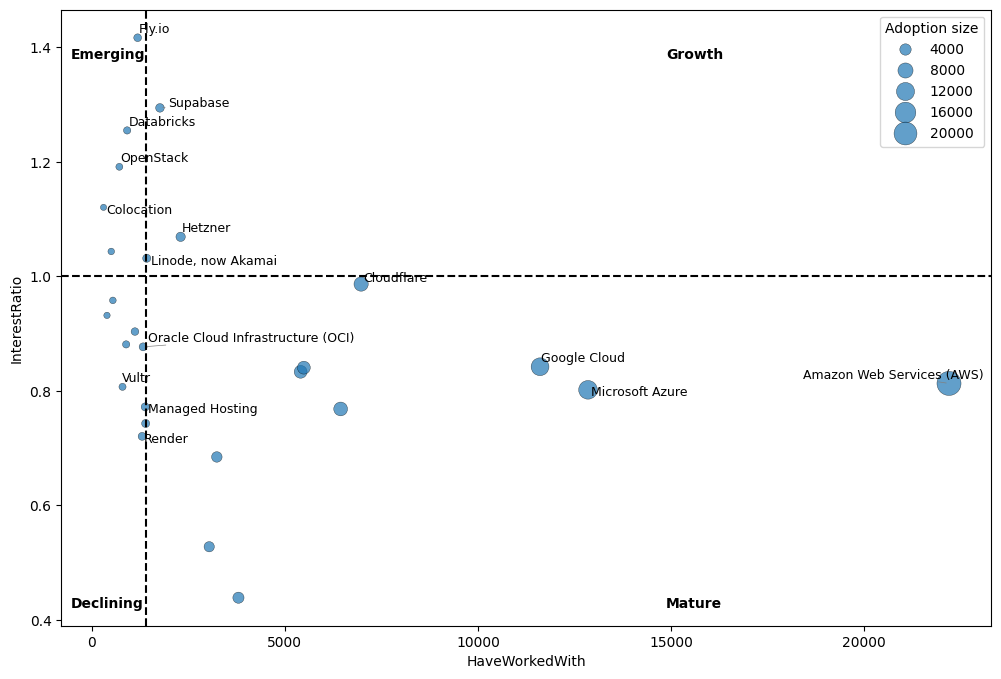

In [10]:
ax_have_prefer = u.quadrant_chart(df_platforms_metrics, 'HaveWorkedWith', 'InterestRatio', x_median, 1, label_df, 'Growth', 'Emerging', 'Declining', 'Mature')
plt.show()

- Amazon Web Services, Microsoft Azure y Google Cloud presentan una gran base de usuarios. Sin embargo, su índice de preferencia cercano a 1 sugiere que su crecimiento relativo es más estable, lo que es consistente con plataformas consolidadas y maduras dentro del mercado cloud.
- Hetzner y Supabase tienen un indice de preferencia mayor a 1, lo que indica que más desarrolladores desean trabajar con estas plataformas en comparación con quienes ya las utilizan, sugiriendo potencial de crecimiento y oportunidades de adopción futura.
- Fly.io, Databricks y OpenStack presentan índices de preferencia relativamente altos pero con una base de usuarios menor, lo que podría indicar tecnologías emergentes con potencial de adopción, aunque aún con menor penetración en el mercado.
- Plataformas como Render y Managed Hosting muestran tanto una base de usuarios como un índice de preferencia relativamente bajos, lo que sugiere menor interés relativo entre los desarrolladores en comparación con otras plataformas analizadas.

In [11]:
x_median = df_plot['InterestRatio'].median()
y_median = df_plot['AdmiredRatio'].median()

df_plot = u.assign_quadrant(
    df_plot,
    'InterestRatio',
    'AdmiredRatio',
    x_median,
    y_median,
    'PerceptionQuadrant',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

leaders = df_plot[df_plot['PerceptionQuadrant'] =='Leaders'].nlargest(4, 'AdmiredRatio')
loved   = df_plot[df_plot['PerceptionQuadrant'] == 'Loved Niche'].nlargest(4, 'AdmiredRatio')
trendy  = df_plot[df_plot['PerceptionQuadrant'] == 'Trendy'].nlargest(4, 'InterestRatio')
weak    = df_plot[df_plot['PerceptionQuadrant'] == 'Weak'].nsmallest(4, 'AdmiredRatio')

label_df = pd.concat([leaders, loved, trendy, weak])

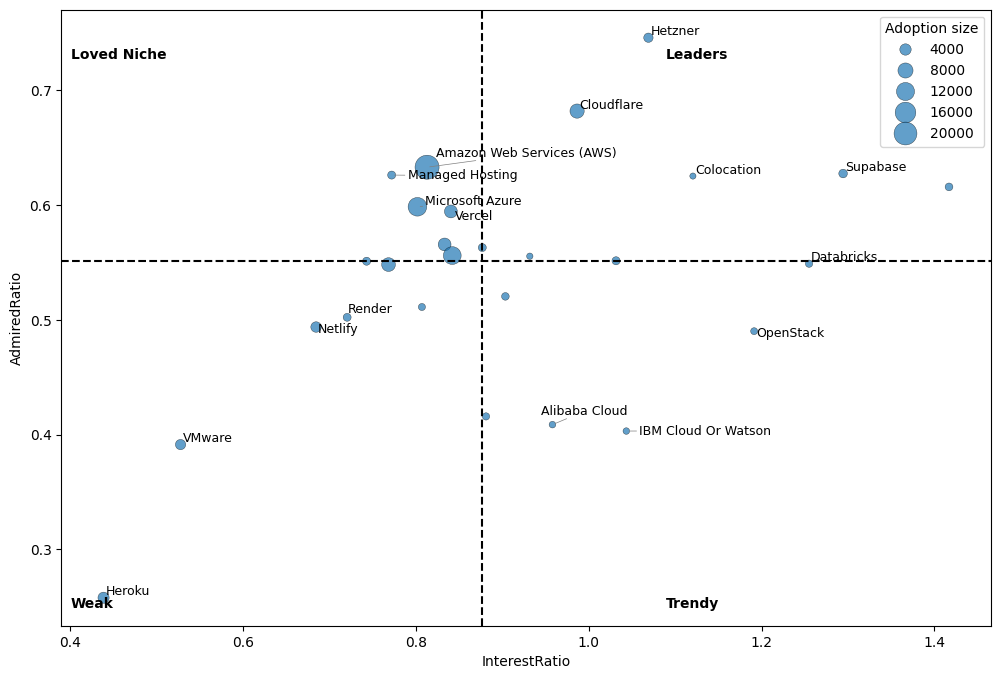

In [12]:
ax_prefer_adm = u.quadrant_chart(
    df_plot,
    'InterestRatio',
    'AdmiredRatio',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

- La mayor parte de las plataformas se concentra en el cuadrante “Loved Niche”, lo que indica tecnologías con alta admiración entre sus usuarios pero con una base de adopción más limitada. En este grupo se encuentran plataformas consolidadas como AWS y Microsoft Azure, que mantienen una percepción positiva entre los profesionales que ya trabajan con ellas.
- Plataformas como Cloudflare y Supabase destacan por combinar altas tasas de preferencia y admiración, posicionándose en el cuadrante de líderes. Esto sugiere tecnologías bien valoradas por la comunidad y con alto potencial de adopción o transición desde otras plataformas.
- OpenStack y OpenShift presentan alta preferencia pero menor nivel de admiración, lo que indica que, aunque existe interés en trabajar con ellas, la percepción entre quienes ya las utilizan es relativamente más baja. Esto puede reflejar desafíos en experiencia de uso, complejidad o satisfacción del desarrollador.
- Por otro lado, plataformas como Render y Heroku muestran niveles bajos tanto de preferencia como de admiración, lo que sugiere un menor dinamismo en términos de crecimiento o interés de adopción dentro del ecosistema durante el último año.

In [13]:
x_median = df_plot['InterestRate'].quantile(0.75)
y_median = df_plot['AdmiredRate'].quantile(0.75)

df_plot = u.assign_quadrant(
    df_plot,
    'InterestRate',
    'AdmiredRate',
    x_median,
    y_median,
    'PerceptionQuadrant2',
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)

In [14]:
leaders = df_plot[df_plot['PerceptionQuadrant2'] =='Leaders'].nlargest(4, 'AdmiredRate')
loved   = df_plot[df_plot['PerceptionQuadrant2'] == 'Loved Niche'].nlargest(4, 'AdmiredRate')
trendy  = df_plot[df_plot['PerceptionQuadrant2'] == 'Trendy'].nlargest(4, 'InterestRate')
weak    = df_plot[df_plot['PerceptionQuadrant2'] == 'Weak'].nsmallest(4, 'AdmiredRate')

label_df = pd.concat([leaders, loved, trendy, weak])

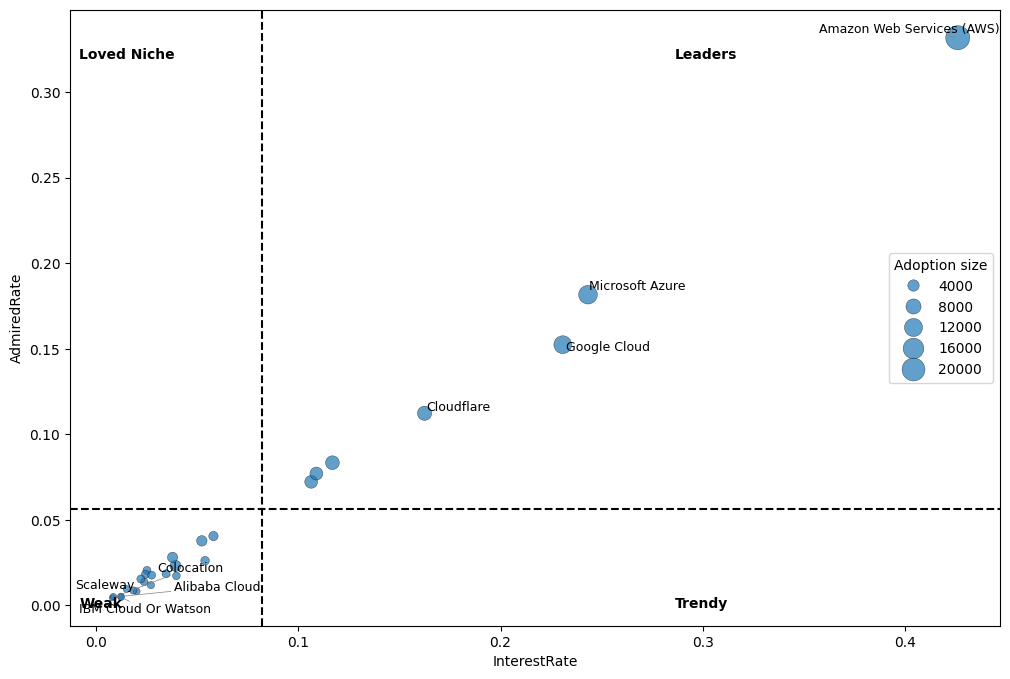

In [15]:
ax_intr_admr = u.quadrant_chart(
    df_plot,
    'InterestRate',
    'AdmiredRate',
    x_median,
    y_median,
    label_df,
    'Leaders',
    'Loved Niche',
    'Weak',
    'Trendy'
)
plt.show()

- Amazon Web Services (AWS) es la tecnología predominante en esta categoría, combinando alta tasa de interés y admiración, asi como una gran base de usuarios, posicionandose como tecnología líder.

In [16]:
comparison = (
    df_plot[
        ['MarketQuadrant', 'PerceptionQuadrant']
    ]
    .reset_index()
    .sort_values(['MarketQuadrant', 'PerceptionQuadrant'])
)

crosstab = pd.crosstab(
    df_plot['MarketQuadrant'],
    df_plot['PerceptionQuadrant']
)

crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_pct

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
MarketQuadrant,,,,
Declining,0.250000,0.125000,0.375,0.250000
Emerging,0.400000,0.000000,0.600,0.000000
Growth,1.000000,0.000000,0.000,0.000000
Mature,0.090909,0.454545,0.000,0.454545


- El 100% de las plataformas clasificadas en el cuadrante de crecimiento también son percibidas como líderes, lo que sugiere que las tecnologías que están expandiendo su adopción en el mercado tienden a mantener altos niveles de preferencia y admiración entre los profesionales.
- El 64% de las plataformas maduras se ubica en el cuadrante “Loved Niche”, lo que indica tecnologías altamente valoradas por sus usuarios pero con menor dinamismo en crecimiento. Esto es consistente con plataformas consolidadas que cuentan con una base amplia de usuarios y un mercado relativamente estabilizado.
- Entre las plataformas emergentes, el 60% es percibido como líder, lo que sugiere que varias tecnologías en fases tempranas de adopción ya presentan una percepción positiva dentro de la comunidad, representando posibles oportunidades de adopción o transición tecnológica.
- Las plataformas en declive muestran una distribución más dispersa entre percepciones, con presencia tanto en categorías Trendy, Leaders y Weak, lo que sugiere que algunas tecnologías pueden mantener cierto interés o percepción positiva aun cuando su dinamismo en el mercado comienza a disminuir.

In [17]:
market_score = {
    'Growth': 3,
    'Emerging': 2,
    'Mature': 1,
    'Declining': 0
}

perception_score = {
    'Leaders': 3,
    'Loved Niche': 2,
    'Trendy': 1,
    'Weak': 0
}

df_plot['MarketScore'] = df_plot['MarketQuadrant'].map(market_score)
df_plot['PerceptionScore'] = df_plot['PerceptionQuadrant'].map(perception_score)

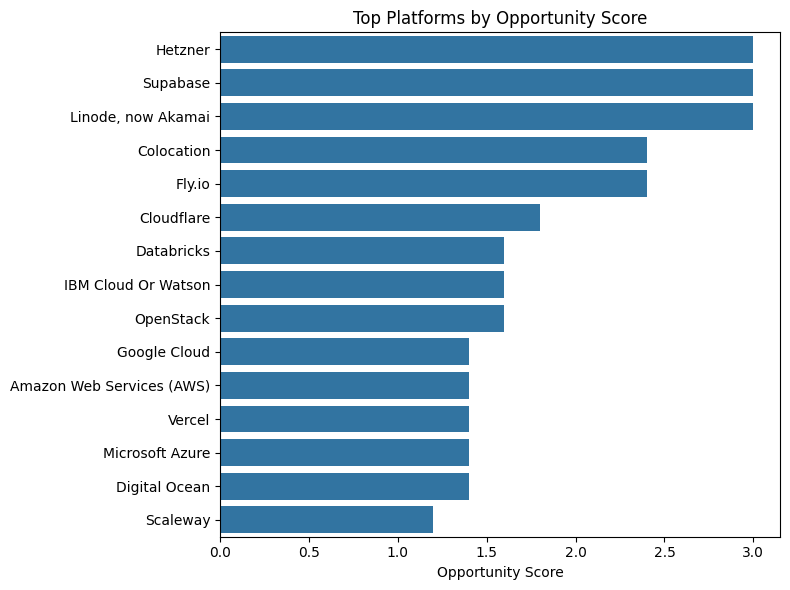

In [18]:
df_plot['OpportunityScore'] = (
    df_plot['MarketScore'] * 0.6 +
    df_plot['PerceptionScore'] * 0.4
)

ranking = (
    df_plot
    .sort_values('OpportunityScore', ascending=False).reset_index()
    [['Platform', 'MarketQuadrant', 'PerceptionQuadrant', 'OpportunityScore']]
)

top = 15

df_rank = (
    df_plot
    .sort_values('OpportunityScore', ascending=False)
    .head(top)
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=df_rank,
    x='OpportunityScore',
    y='Platform'
)

plt.title('Top Platforms by Opportunity Score')
plt.xlabel('Opportunity Score')
plt.ylabel('')

plt.tight_layout()
plt.show()

En general, el mayor Opportunity Score se concentra en plataformas alternativas o en crecimiento, como Hetzner, Supabase y Linode, mientras que los grandes proveedores de nube como AWS, Microsoft Azure y Google Cloud presentan valores más moderados. Esto sugiere que las mayores oportunidades de adopción o exploración tecnológica podrían estar emergiendo fuera de los proveedores tradicionales dominantes.

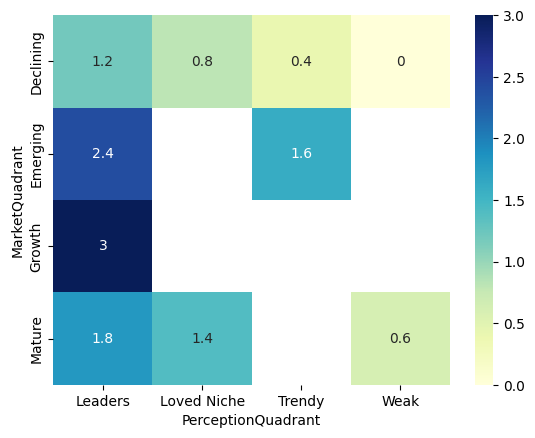

In [19]:
pivot = (
    df_plot
    .pivot_table(
        values = 'OpportunityScore',
        index = 'MarketQuadrant',
        columns = 'PerceptionQuadrant'
    )
)

sns.heatmap(pivot, annot = True, cmap = 'YlGnBu')
plt.show()

In [20]:
df_plot['AlignmentGap'] = (
    df_plot['PerceptionScore'] - df_plot['MarketScore']
)

df_plot.sort_values('AlignmentGap', ascending=False)['AlignmentGap'].head(5)

Platform
Scaleway                             3
Oracle Cloud Infrastructure (OCI)    3
Cloudflare                           2
Managed Hosting                      2
Colocation                           1
Name: AlignmentGap, dtype: int64

Scaleway y OCI presentan una alineacion elevada, superior a su posición en el mercado, lo que indica posibles oportunidades de crecimiento impulsadas por entusiasmo y admiración de la comunidad.

In [21]:
df_plot.sort_values('AlignmentGap')['AlignmentGap'].head(5)

Platform
Firebase              -1
Databricks            -1
IBM Cloud Or Watson   -1
Heroku                -1
Netlify               -1
Name: AlignmentGap, dtype: int64

IBM Cloud Or Watson presentan una alineación negativa, indicando menos oportunidades de crecimiento dentro del ecosistema.

In [22]:
df_pf_exp = (
    df_platforms
    .merge(df_respondents[['ResponseId', 'YearsCodePro', 'Age_Group', 'RemoteWork_Clean', 'EdLevel_Group', 'Country']], on = 'ResponseId')
)
df_pf_exp.head()

,ResponseId,Platform,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country
0,2,Amazon Web Services (AWS),HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
1,2,Heroku,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
2,2,Netlify,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR
3,3,Google Cloud,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR
4,4,Amazon Web Services (AWS),HaveWorkedWith,NaN,18-24,Not specified,No Formal Degree,CAN


In [23]:
df_analysis = df_pf_exp.merge(
    df_plot.reset_index()[['Platform', 'MarketQuadrant', 'PerceptionQuadrant', 
             'MarketScore', 'PerceptionScore', 'OpportunityScore', 'AlignmentGap']],
    on = 'Platform',
    how = 'left'
)
df_analysis.head()

,ResponseId,Platform,Relation,YearsCodePro,Age_Group,RemoteWork_Clean,EdLevel_Group,Country,MarketQuadrant,PerceptionQuadrant,MarketScore,PerceptionScore,OpportunityScore,AlignmentGap
0,2,Amazon Web Services (AWS),HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
1,2,Heroku,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Weak,1,0,0.6,-1
2,2,Netlify,HaveWorkedWith,17.0,35-44,Remote,Undergraduate Degree,GBR,Mature,Weak,1,0,0.6,-1
3,3,Google Cloud,HaveWorkedWith,27.0,45-54,Remote,Postgraduate Degree,GBR,Mature,Loved Niche,1,2,1.4,1
4,4,Amazon Web Services (AWS),HaveWorkedWith,NaN,18-24,Not specified,No Formal Degree,CAN,Mature,Loved Niche,1,2,1.4,1


In [24]:
df_analysis['MarketQuadrant'].isna().sum()

np.int64(0)

In [25]:
df_plot.reset_index()['Platform'].nunique() == len(df_plot)

True

In [26]:
len(df_pf_exp) == len(df_analysis)

True

In [27]:
(
    df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']
    .groupby('MarketQuadrant')['YearsCodePro']
    .mean()
    .sort_values()
)

MarketQuadrant
Growth        9.517566
Mature       10.066098
Declining    10.125578
Emerging     10.938720
Name: YearsCodePro, dtype: float64

Se observa que el promedio de experiencia profesional es similar entre los diferentes cuadrantes del mercado, con valores que oscilan entre 9.5 y 10.9 años. Esto indica que la adopción o percepción de las plataformas no parece estar fuertemente influenciada por el nivel de experiencia de los profesionales.

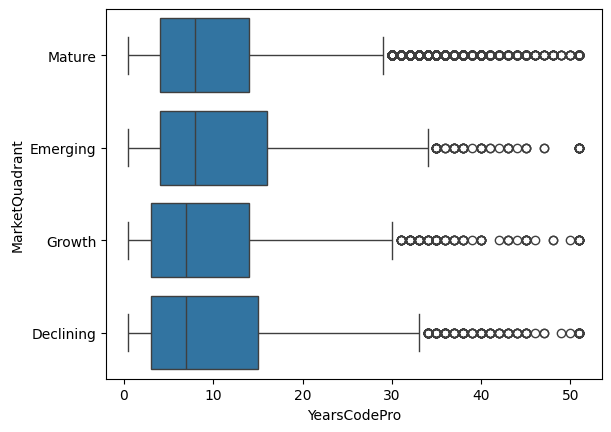

In [28]:
sns.boxplot(
    data=df_analysis[df_analysis['Relation'] == 'HaveWorkedWith'],
    x = 'YearsCodePro',
    y = 'MarketQuadrant'
)
plt.show()

En general, la distribución de años de experiencia profesional es similar entre los distintos cuadrantes del mercado (Growth, Mature, Emerging y Declining). Las medianas y rangos intercuartílicos presentan valores cercanos, lo que sugiere que el nivel de experiencia de los desarrolladores no varía significativamente según la posición de las plataformas en el mercado. Además, en todos los cuadrantes se observan outliers con alta experiencia, indicando la presencia de profesionales muy experimentados en cada categoría.

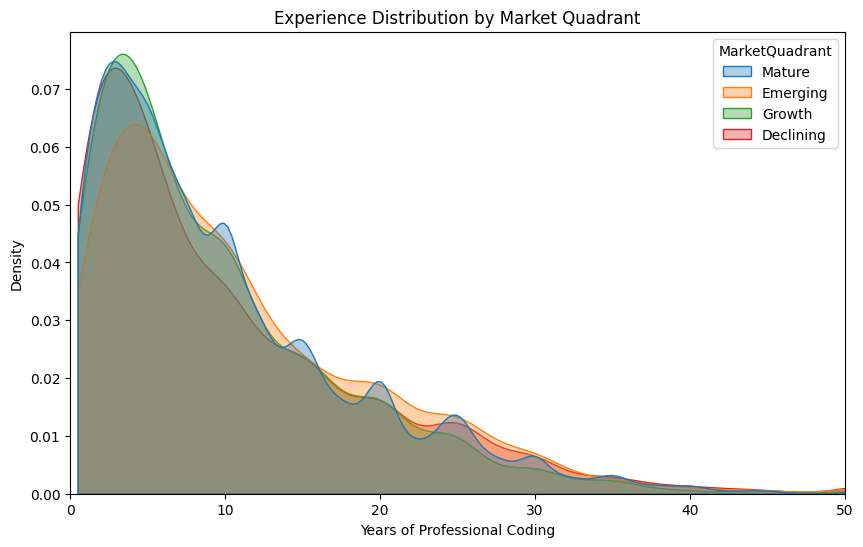

In [29]:
df_plot2 = df_analysis[df_analysis['Relation'] == 'HaveWorkedWith']

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_plot2,
    x = 'YearsCodePro',
    hue = 'MarketQuadrant',
    common_norm = False,
    fill = True,
    alpha = 0.35,
    cut = 0
)
plt.xlim(0,50)
plt.xlabel('Years of Professional Coding')
plt.ylabel('Density')
plt.title('Experience Distribution by Market Quadrant')
plt.show()

En general, la distribución de años de experiencia profesional es muy similar entre los distintos cuadrantes del mercado (Mature, Emerging, Growth y Declining). Todas las curvas muestran una mayor concentración de profesionales con menos de 10 años de experiencia, seguida de una disminución progresiva conforme aumenta la experiencia. Esto sugiere que la participación de desarrolladores en distintas plataformas del ecosistema cloud no presenta diferencias importantes según el nivel de experiencia profesional.

In [30]:
pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize = 'index'
)

PerceptionQuadrant,Leaders,Loved Niche,Trendy,Weak
Age_Group,,,,
18-24,0.203926,0.524358,0.043432,0.228284
25-34,0.171301,0.606392,0.046501,0.175806
35-44,0.170478,0.631617,0.053369,0.144536
45-54,0.154397,0.653240,0.058172,0.134192
55-64,0.133464,0.676393,0.063242,0.126902
65+,0.144550,0.639810,0.072670,0.142970
Under 18,0.268978,0.421362,0.041940,0.267720
Unknown,0.215054,0.494624,0.091398,0.198925


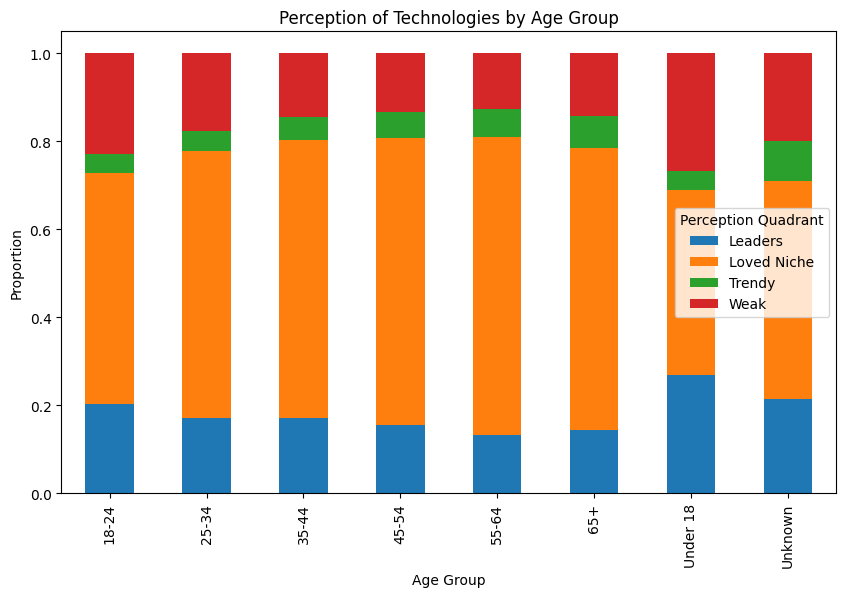

In [31]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Perception of Technologies by Age Group')
plt.legend(title = 'Perception Quadrant')
plt.show()

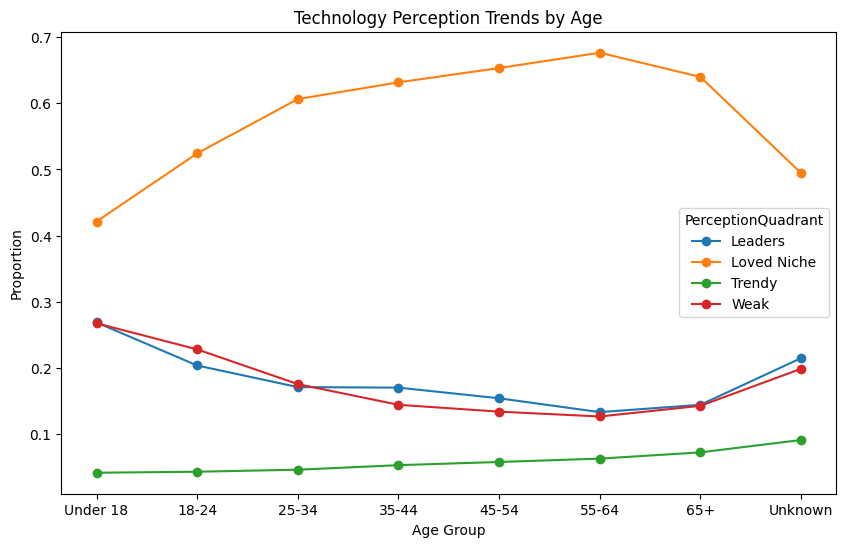

In [32]:
ct = pd.crosstab(
    df_analysis['Age_Group'],
    df_analysis['PerceptionQuadrant'],
    normalize='index'
)

order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
ct = ct.loc[order]

ct.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.title('Technology Perception Trends by Age')
plt.show()

La percepción de tecnologías “Loved Niche” domina en todos los grupos de edad, alcanzando sus valores más altos entre los desarrolladores de 25 a 64 años. En contraste, la proporción de tecnologías percibidas como líderes tiende a disminuir ligeramente en los grupos de edad intermedios. Esto sugiere que los desarrolladores con más experiencia tienden a valorar tecnologías especializadas o de nicho dentro del ecosistema tecnológico.